In [13]:
import os 
import numpy as np 
import matplotlib.pyplot as plt 
from qiskit_aer.primitives import Estimator 
from qiskit.quantum_info import Statevector, random_clifford 

In [14]:
from tomography import SelfGuidedTomography, Mean_Direct_Fidelity, NearSparseTomography

### Initial Parameters

In [15]:
NQs = [2, 3, 4, 6, 8]
L = len(NQs)
N = 10
Niter = 10
shots = 1000

simulator_ideal = Estimator(
    backend_options={
        "shots": shots,
        "method": "stabilizer",
    },
    transpile_options={"optimization_level": 0},
)

In [16]:
def simulate(NQ, simulator=simulator_ideal):
    d = 2 ** NQ

    Omega = random_clifford(NQ).to_circuit()
    OmegaM = np.outer(
        np.array(Statevector(Omega)), (np.array(Statevector(Omega))).conj()
    )

    psi0 = np.random.rand(d) + 1j * np.random.rand(d)
    psi0 = psi0 / np.linalg.norm(psi0)
    guess = psi0

    MDF = Mean_Direct_Fidelity(NQ)

    purities  = []
    stop_measuring_flag = [False]
    def stop_measuring(MDF):

        if stop_measuring_flag[0]:
            return True
        
        purities.append(MDF.Purity)
        diffs = np.diff(purities[-3:])
        
        conditions = np.isclose(diffs, 0.0, atol=1e-5)
        if len(conditions) < 2:
            conditions = [False]
        
        all_conditions = np.all(conditions) and (MDF.Purity > 0.9)
        
        if all_conditions:
            stop_measuring_flag[0] = True
            print("Stopping measurement")
        
        return all_conditions

    def I_ex(x):
        return 1 - MDF.MeanFidelity(
            1,
            NQ**2,
            x,
            Omega,
            simulator,
            truncation=None,
            stop_measuring=stop_measuring,
        )

    def I_th(x):
        return 1 - np.vdot(x, OmegaM @ x) / (np.linalg.norm(x)) ** 2

    Fidelities = []
    Measures = []
    Last = []
    norms = []

    def callback(i, x):
        Last.append(x)
        Fidelities.append(np.real(I_th(x)))
        Measures.append(len(MDF.Measures))
        nnn = np.linalg.norm( list( MDF.Measures.values() ) )**2
        norms.append( nnn )
        return None

    def postprocessing(x):
        return NearSparseTomography(x, MDF=MDF)

    SelfGuidedTomography(
        I_ex,
        guess,
        num_iter=Niter,
        callback=callback,
        postprocessing=postprocessing,
    )

    Results = [
        np.array(Fidelities),
        np.array(Measures),
        np.array(Last),
        np.array(norms), 
    ]

    return Results  # j index the average over the Hilbert space

In [17]:
from joblib import Parallel, delayed

iterator = np.repeat(NQs, N).flatten()

R = Parallel(n_jobs=-1, verbose=11)(delayed(simulate)(int(NQ)) for NQ in iterator)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done   3 out of  50 | elapsed:    6.2s remaining:  1.6min
[Parallel(n_jobs=-1)]: Done   8 out of  50 | elapsed:    7.1s remaining:   37.4s


Stopping measurement
Stopping measurement
Stopping measurement


[Parallel(n_jobs=-1)]: Done  13 out of  50 | elapsed:   10.6s remaining:   30.2s
[Parallel(n_jobs=-1)]: Done  18 out of  50 | elapsed:   11.7s remaining:   20.8s


Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement
Stopping measurement


[Parallel(n_jobs=-1)]: Done  23 out of  50 | elapsed:   20.7s remaining:   24.3s
[Parallel(n_jobs=-1)]: Done  28 out of  50 | elapsed:   24.2s remaining:   19.0s
[Parallel(n_jobs=-1)]: Done  33 out of  50 | elapsed:  6.0min remaining:  3.1min
[Parallel(n_jobs=-1)]: Done  38 out of  50 | elapsed:  7.3min remaining:  2.3min
[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed: 210.8min remaining: 34.3min
[Parallel(n_jobs=-1)]: Done  48 out of  50 | elapsed: 223.4min remaining:  9.3min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed: 255.7min finished


In [18]:
Fids, Meas, _, Norm = [[[R[i + j * N][r] for i in range(N)] for j in range(len(NQs))]
                   for r in range(4)]

Fids = np.real(Fids)
Meas = np.array(Meas)
Norm = np.array(Norm) 

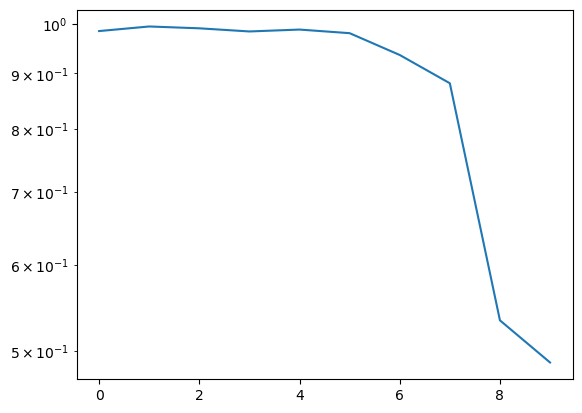

In [19]:
plt.semilogy( np.mean( Fids[-1], axis=0 ) )

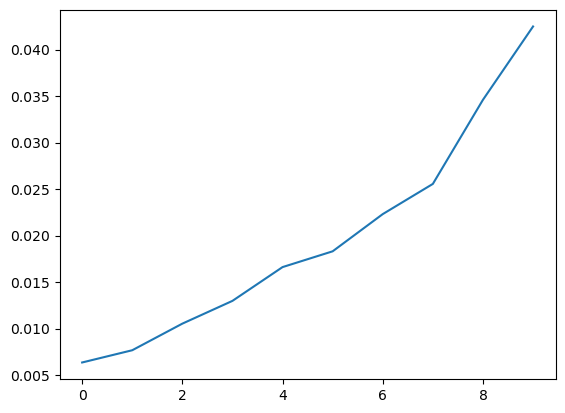

In [20]:
plt.plot( np.mean( Norm[-1], axis=0 ) )

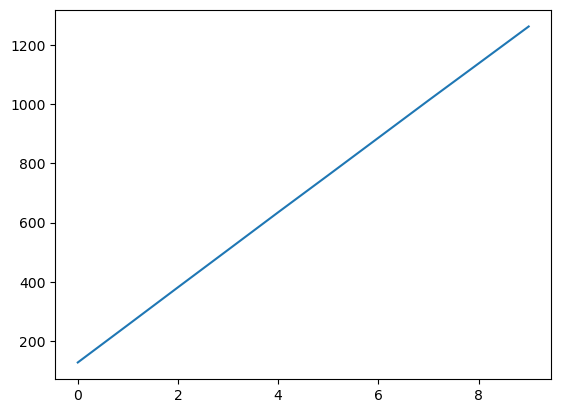

In [21]:
plt.plot( np.mean( Meas[-1], axis=0 ) )

In [22]:
# Save data. Ax order Fids and Meas are: [NQ, Nrun, Niter]

filename = "sgqt_with_postprocessing_stop.npz"

data = {
    "N": [N],
    "shots": [shots],
    "Niter": [Niter],
    "NQs": NQs,
    "Fids": Fids,
    "Meas": Meas,
    "info": ["N, shots, and Niter are single integers in one array each.",
             "NQs is the array of number of qubits.",
             "Fids and Meas have shapes (len(NQs), N, Niter)"],
}

# Make directory "data" if not present
os.makedirs("data", exist_ok=True)

# Save
filepath = os.path.join("data", filename)
np.savez(filepath, **data)